Loaded dataset with shape: (1200, 14)
Columns: ['StudentID', 'Gender', 'Age', 'SchoolType', 'ParentalEducation', 'StudyHours', 'AttendancePercent', 'ExtraClasses', 'InternetAccess', 'PreviousScore', 'TestPrepCourse', 'SocioeconomicStatus', 'Score', 'Pass']
Using target column: 'Pass'

=== Class Distribution ===
Pass
1    0.904167
0    0.095833
Name: proportion, dtype: float64
⚠️  Warning: One class dominates (<10%). Accuracy may be misleading. Focus on per-class and macro F1.

-- Basic EDA --
Shape: (1200, 14)
                      count unique        top  freq       mean        std  \
StudentID              1200   1200  STUD11183     1        NaN        NaN   
Gender                 1200      3     Female   602        NaN        NaN   
Age                  1200.0    NaN        NaN   NaN  16.555833     1.7086   
SchoolType             1200      2     Public   824        NaN        NaN   
ParentalEducation      1200      5   Bachelor   363        NaN        NaN   
StudyHours           1

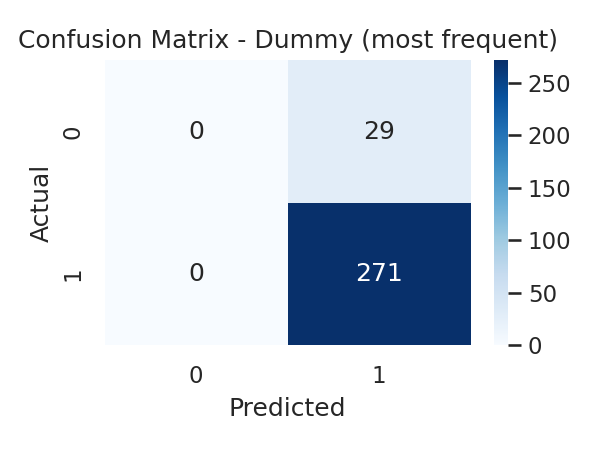

Displaying: cm_Dummy_(most_frequent)_default.png


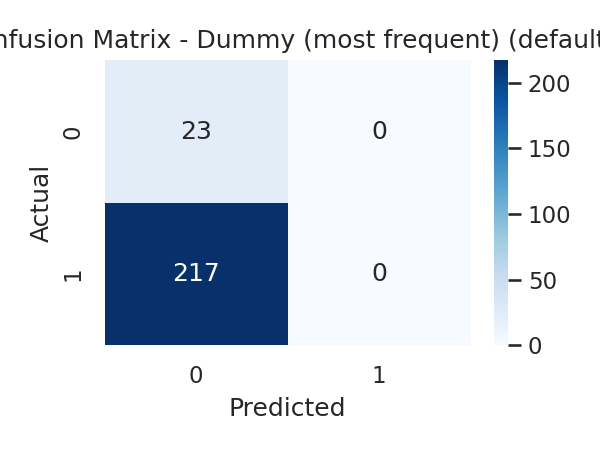

Displaying: cm_Dummy_(most_frequent)_tuned.png


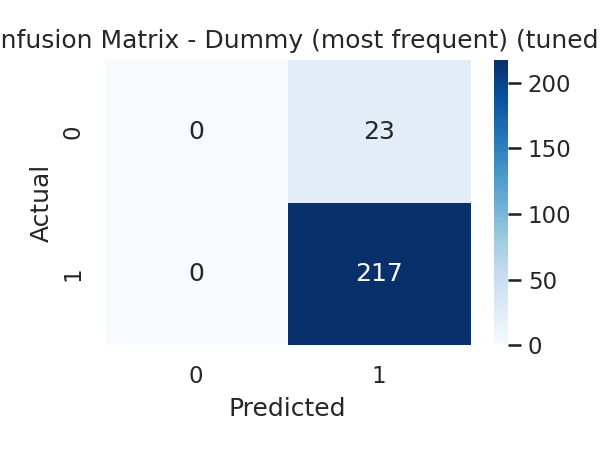

Displaying: cm_Gradient_Boosting.png


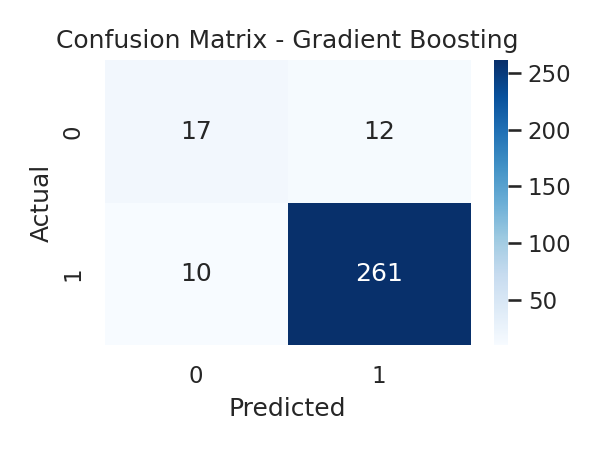

Displaying: cm_Gradient_Boosting_default.png


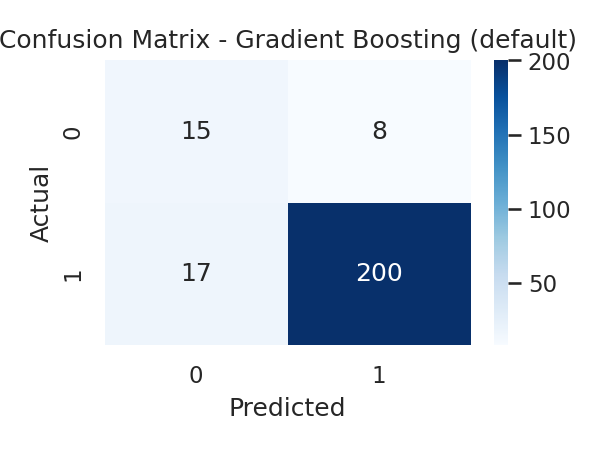

Displaying: cm_Gradient_Boosting_tuned.png


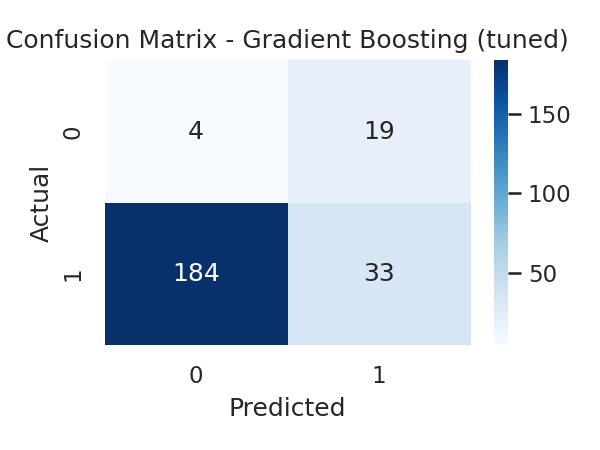

Displaying: cm_Logistic_Regression.png


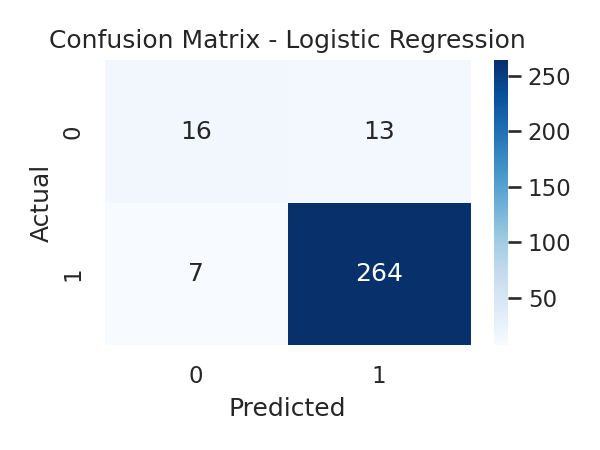

Displaying: cm_Logistic_Regression_(balanced).png


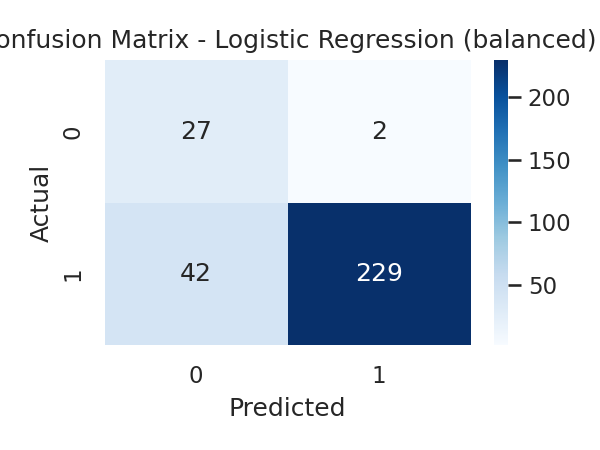

Displaying: cm_Logistic_Regression_(balanced)_default.png


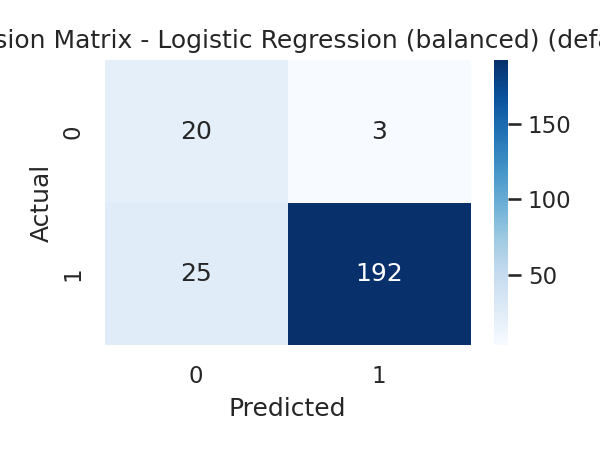

Displaying: cm_Logistic_Regression_(balanced)_tuned.png


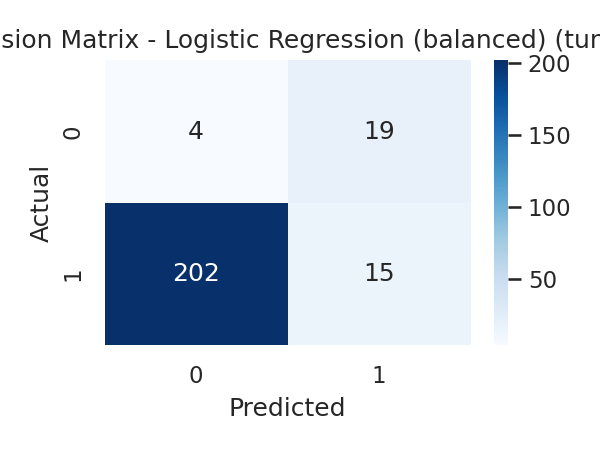

Displaying: cm_Neural_Network_(MLP).png


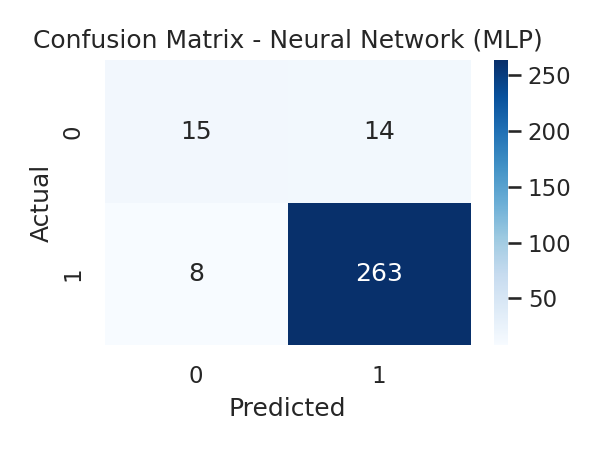

Displaying: cm_Neural_Network_(MLP)_default.png


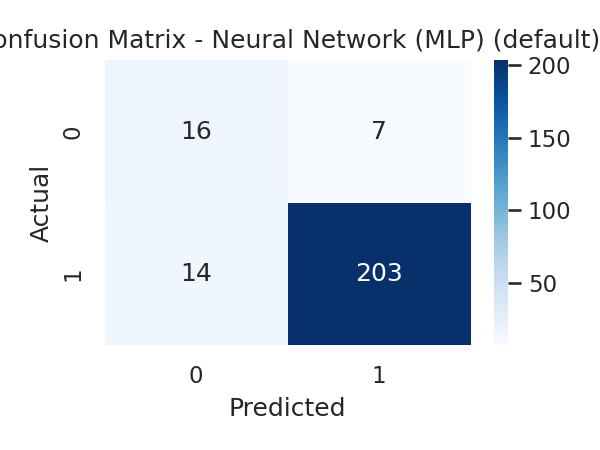

Displaying: cm_Neural_Network_(MLP)_tuned.png


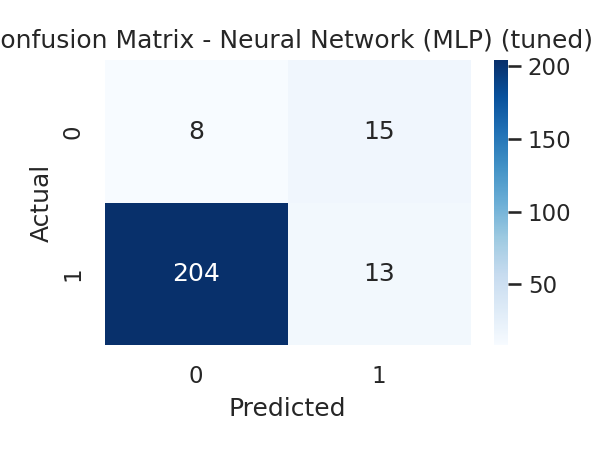

Displaying: cm_Random_Forest.png


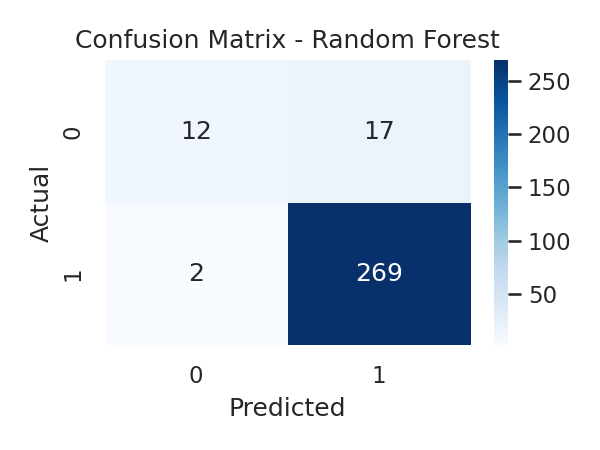

Displaying: cm_Random_Forest_(balanced).png


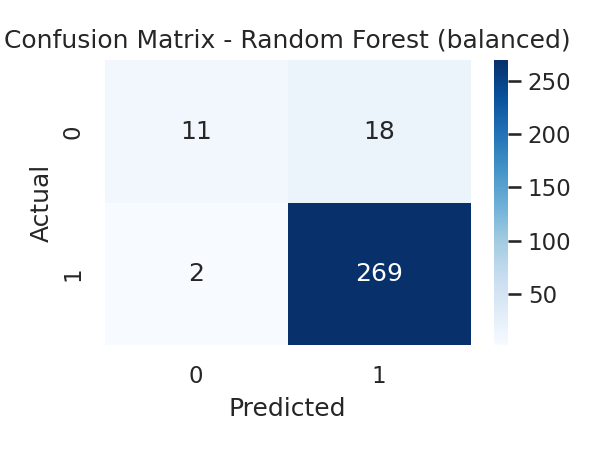

Displaying: cm_Random_Forest_(balanced)_default.png


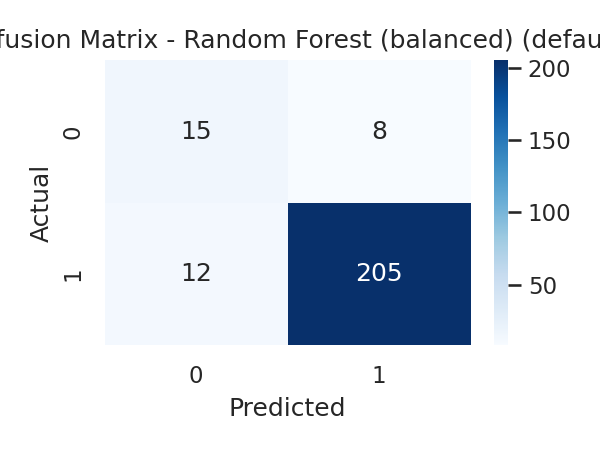

Displaying: cm_Random_Forest_(balanced)_tuned.png


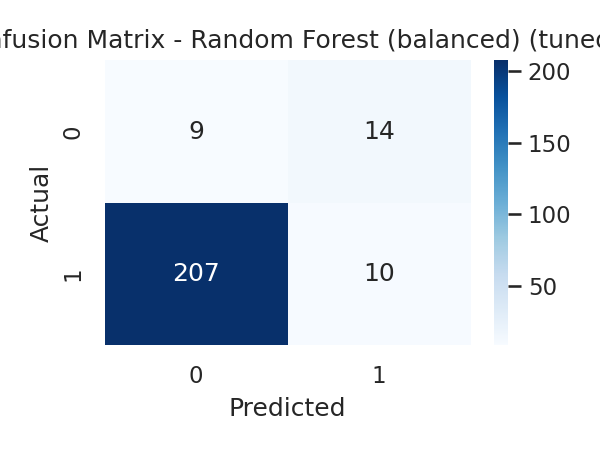

Displaying: cm_SVM_(RBF).png


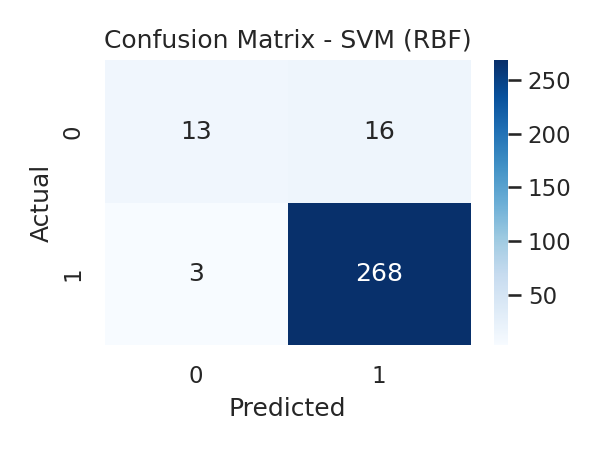

Displaying: cm_SVM_(RBF,_balanced).png


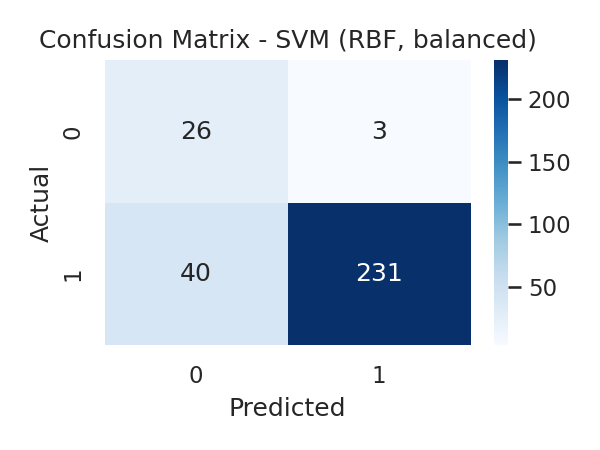

Displaying: cm_SVM_(RBF,_balanced)_default.png


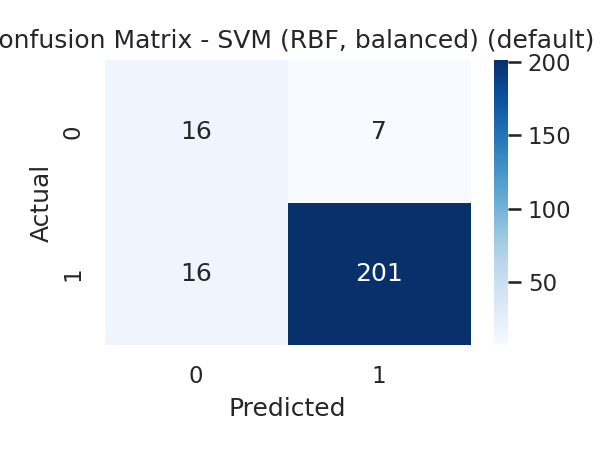

Displaying: cm_SVM_(RBF,_balanced)_tuned.png


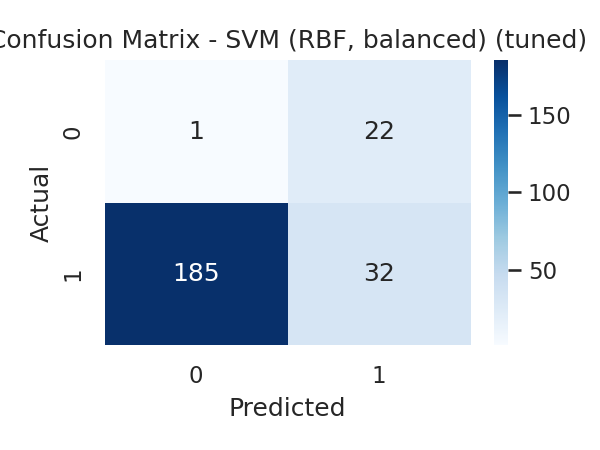

Displaying: confusion_matrix.png


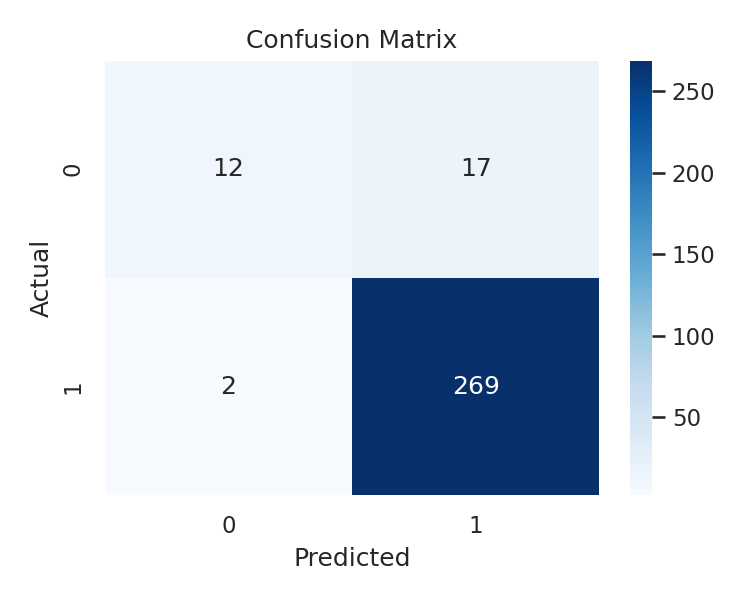

Displaying: correlation_heatmap.png


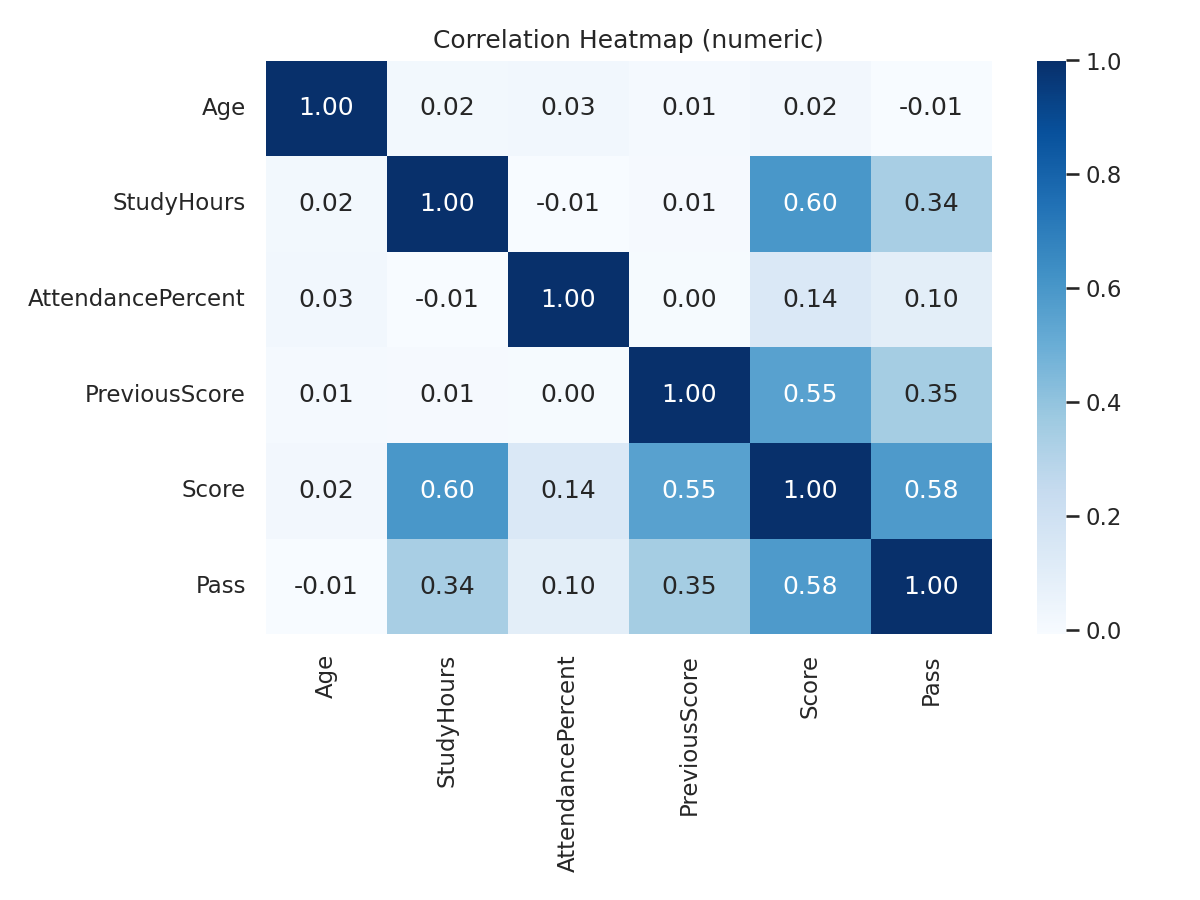

Displaying: feature_importances.png


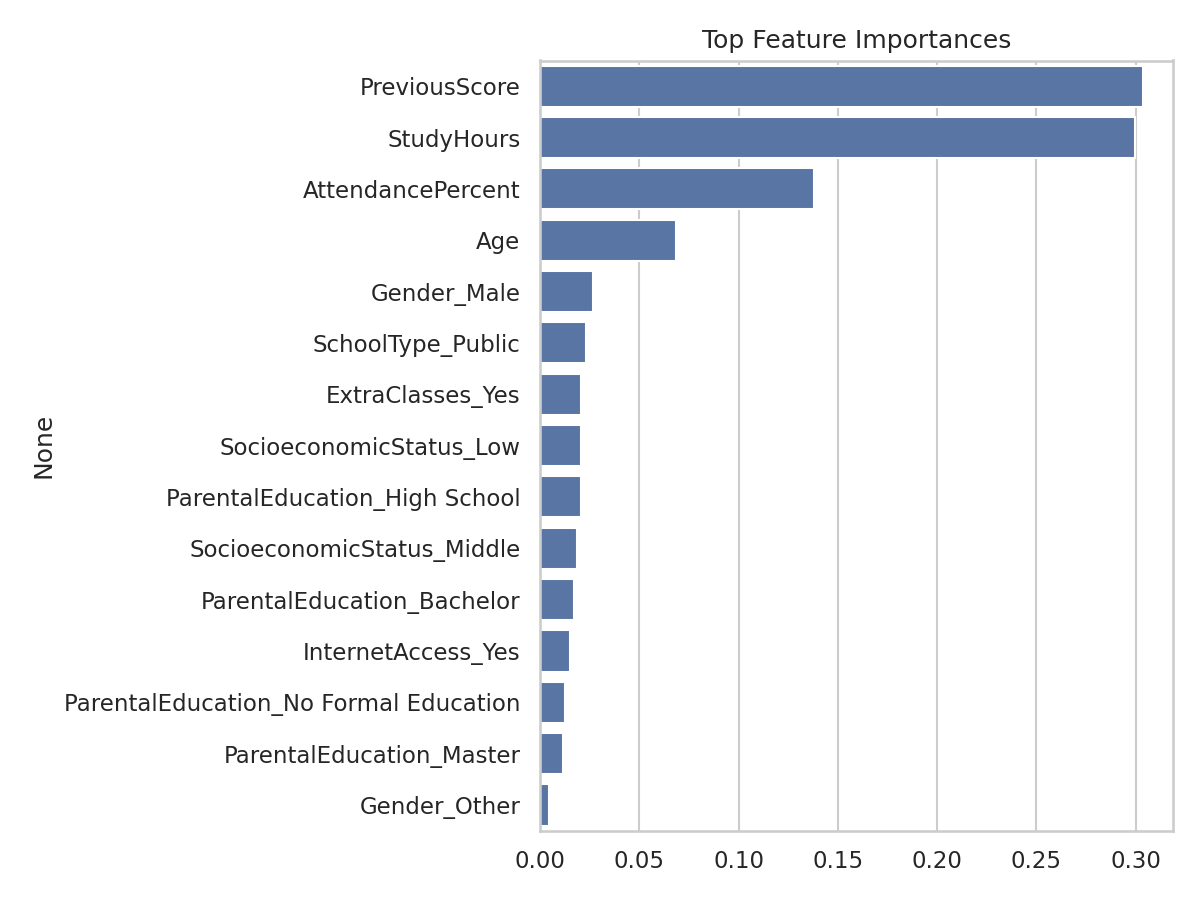

Displaying: linkedin_model_comparison.png


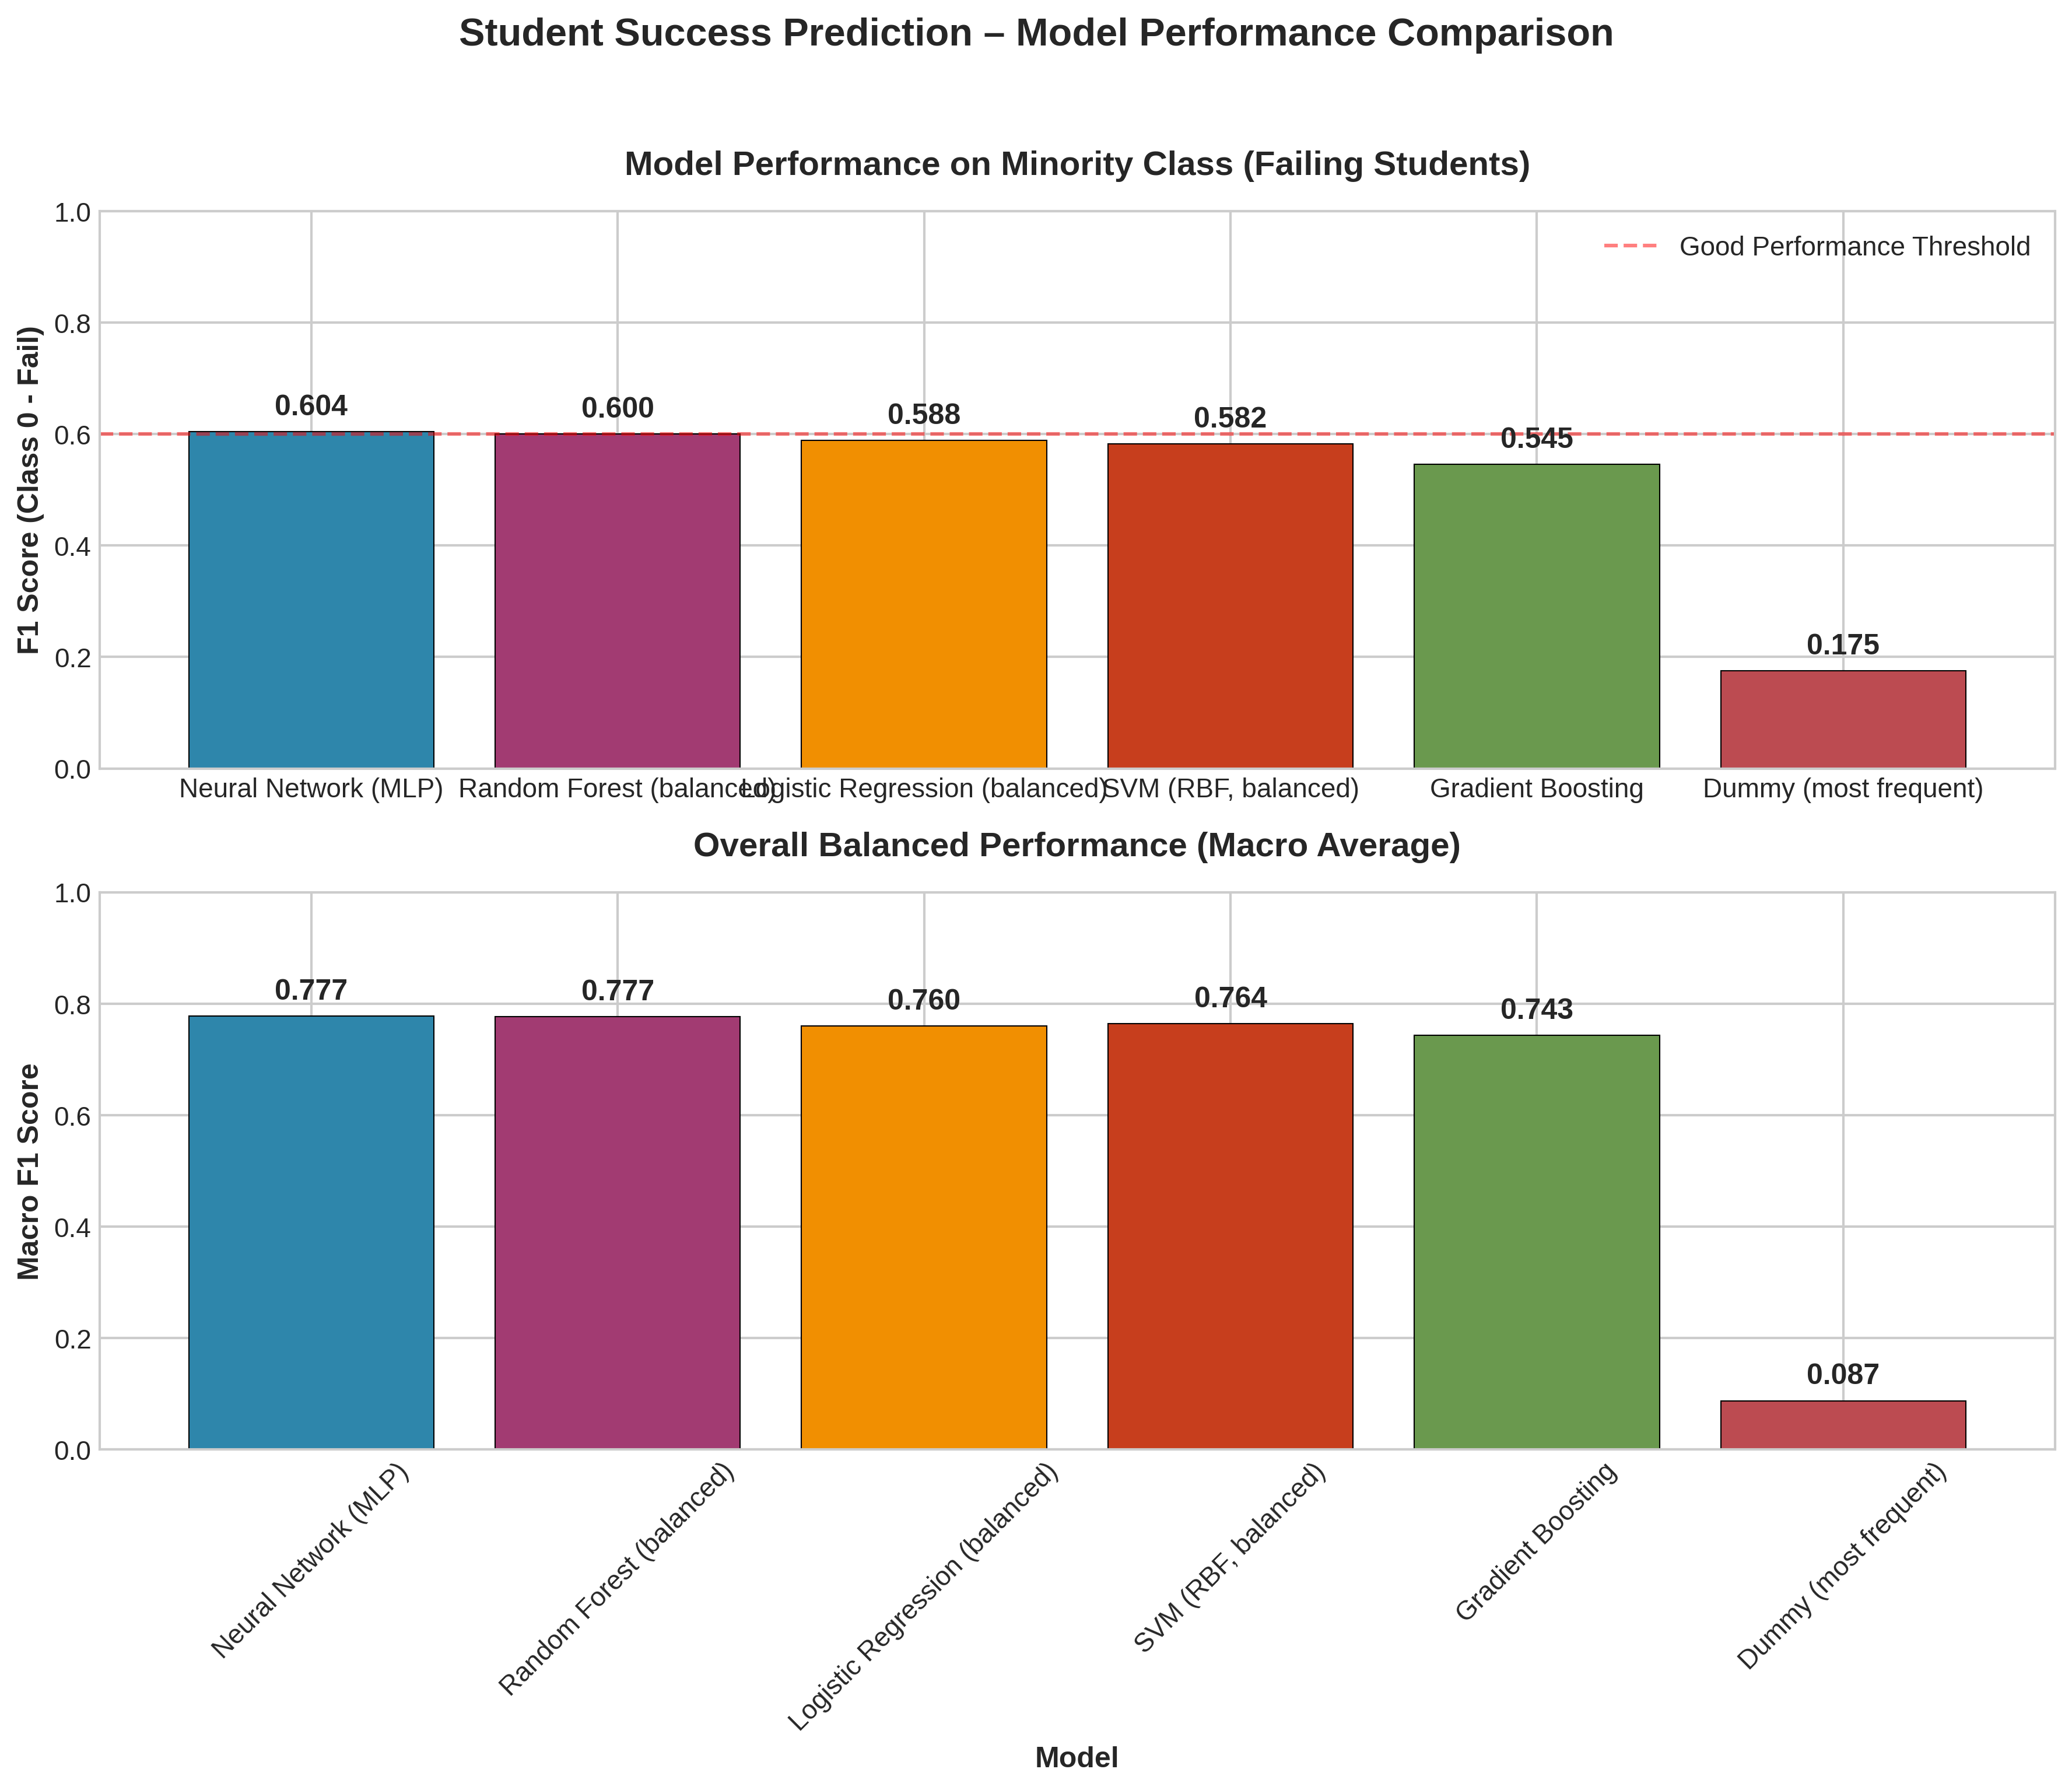

Displaying: model_comparison.png


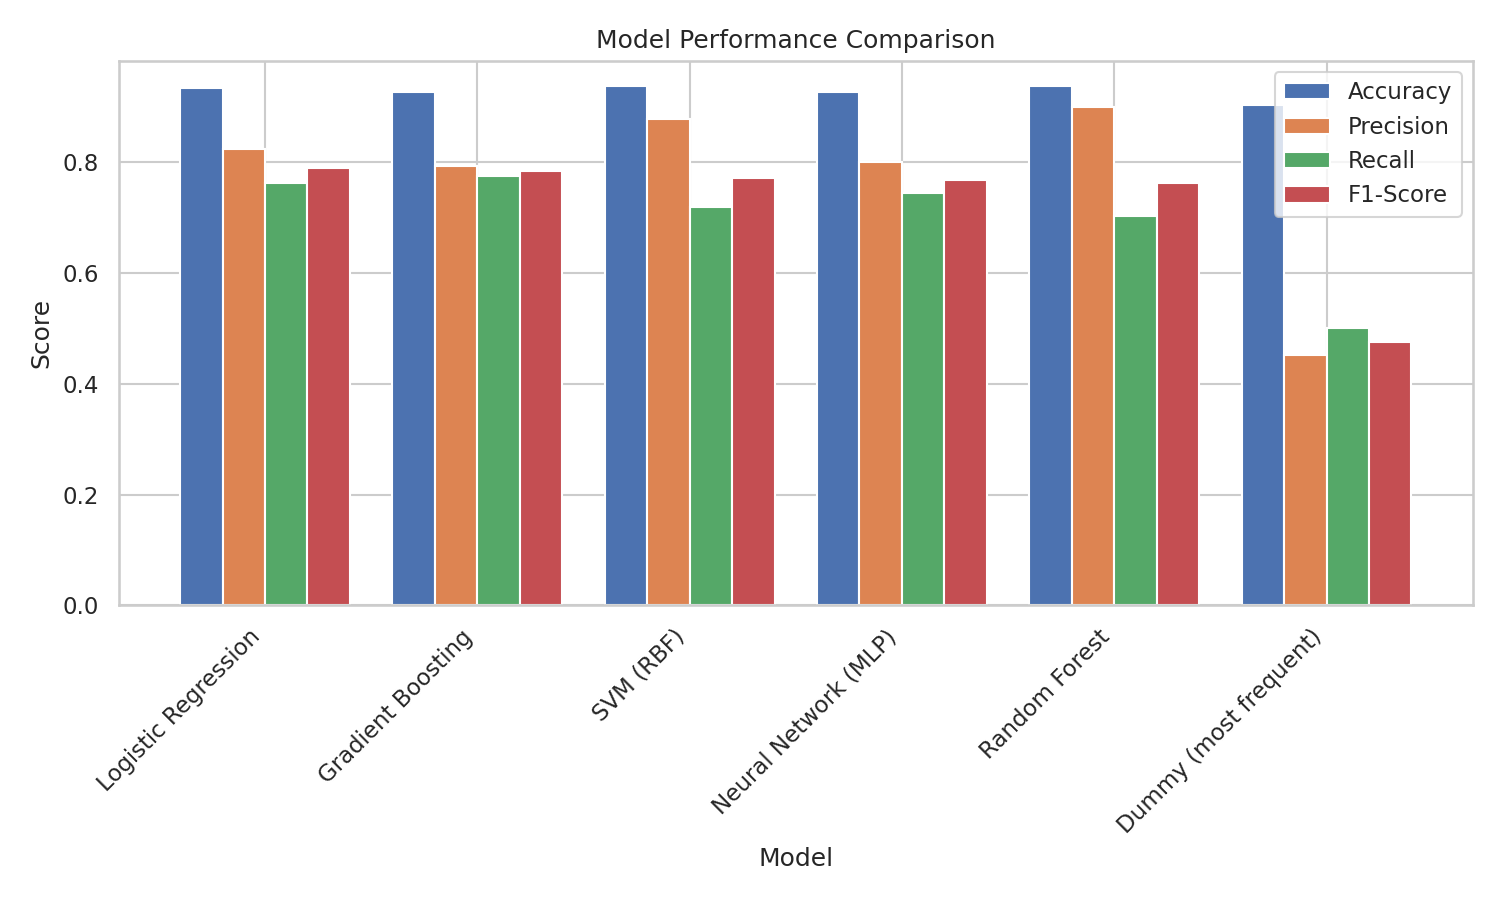

Displaying: model_comparison_f1.png


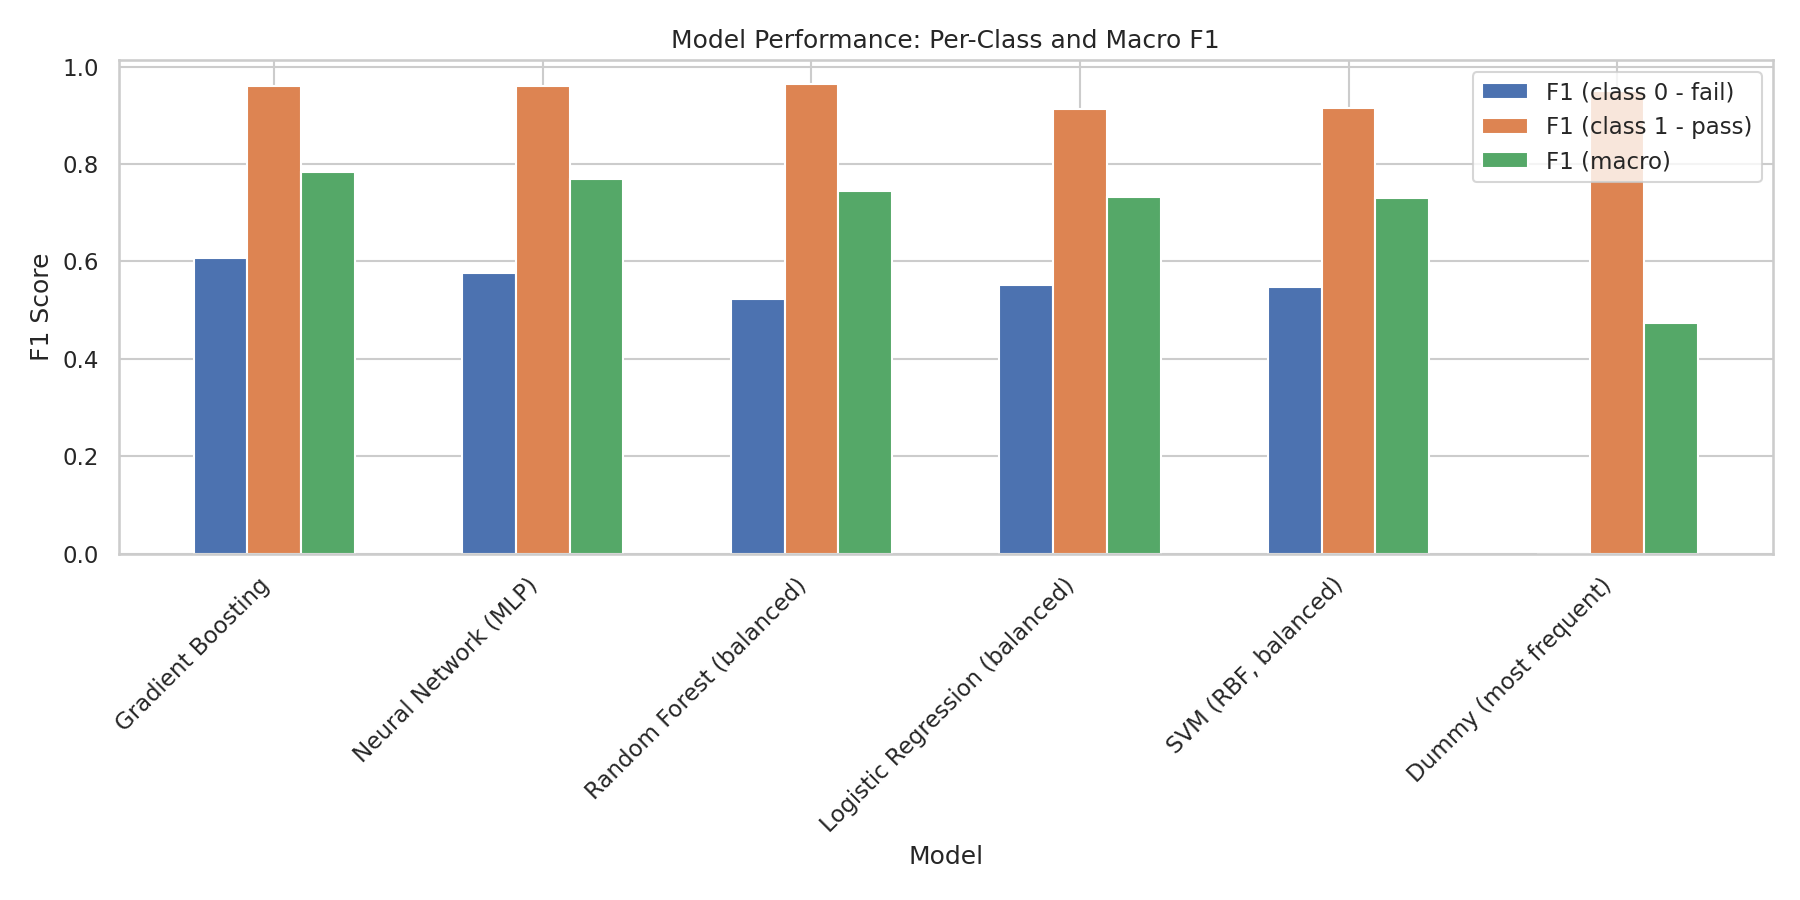

Displaying: score_by_schooltype.png


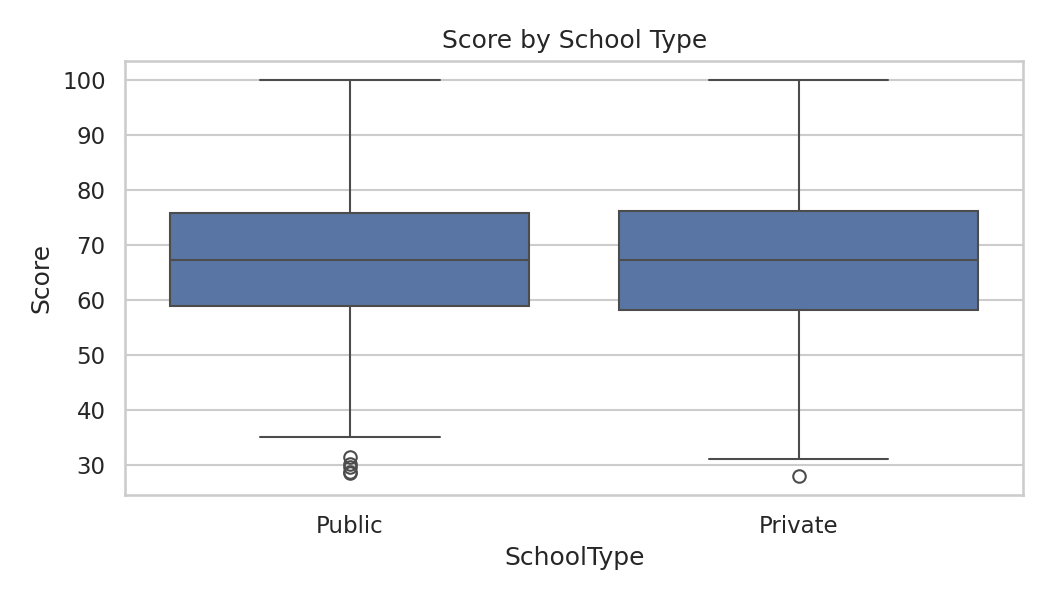

Displaying: score_distribution.png


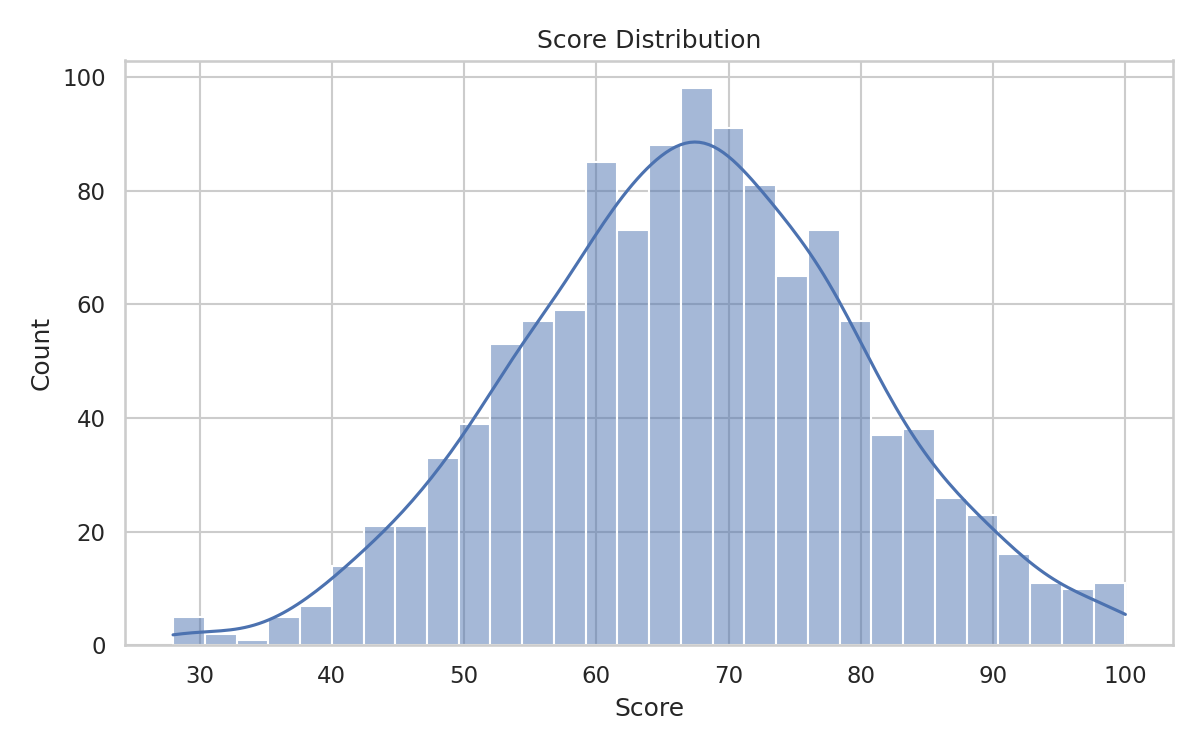

Displaying: threshold_impact.png


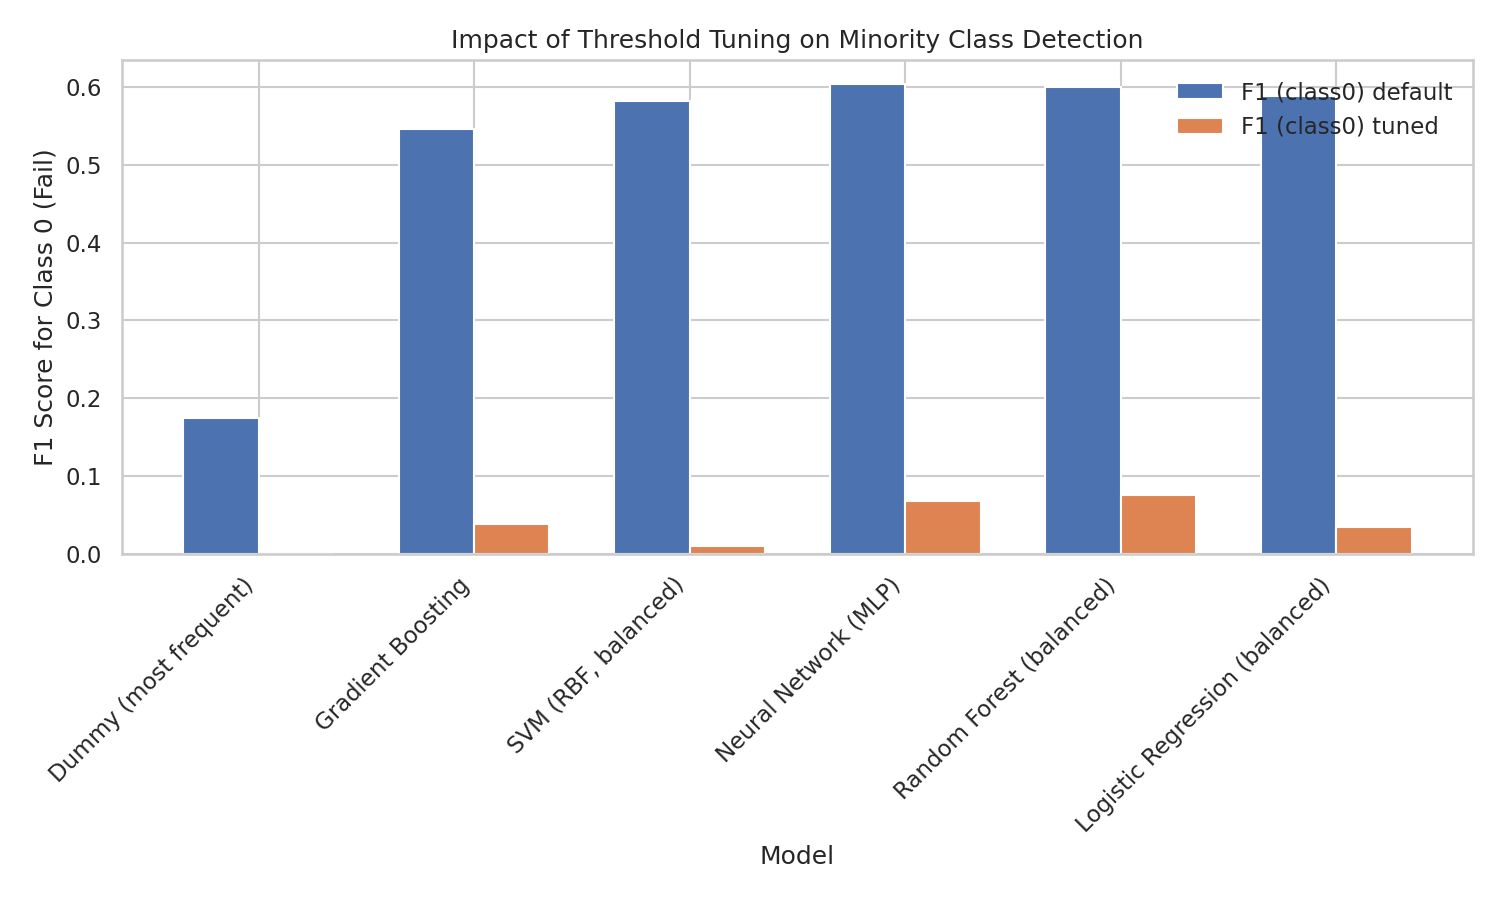

Displaying: threshold_tune_DummyClassifier.png


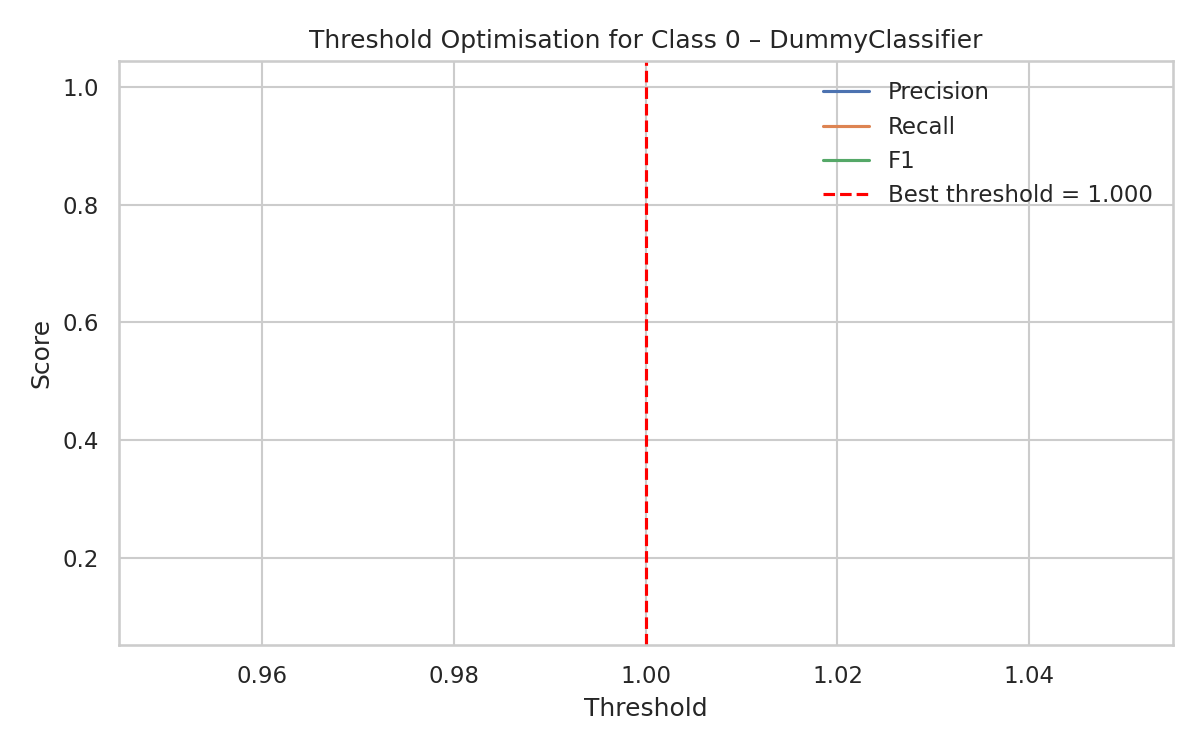

Displaying: threshold_tune_GradientBoostingClassifier.png


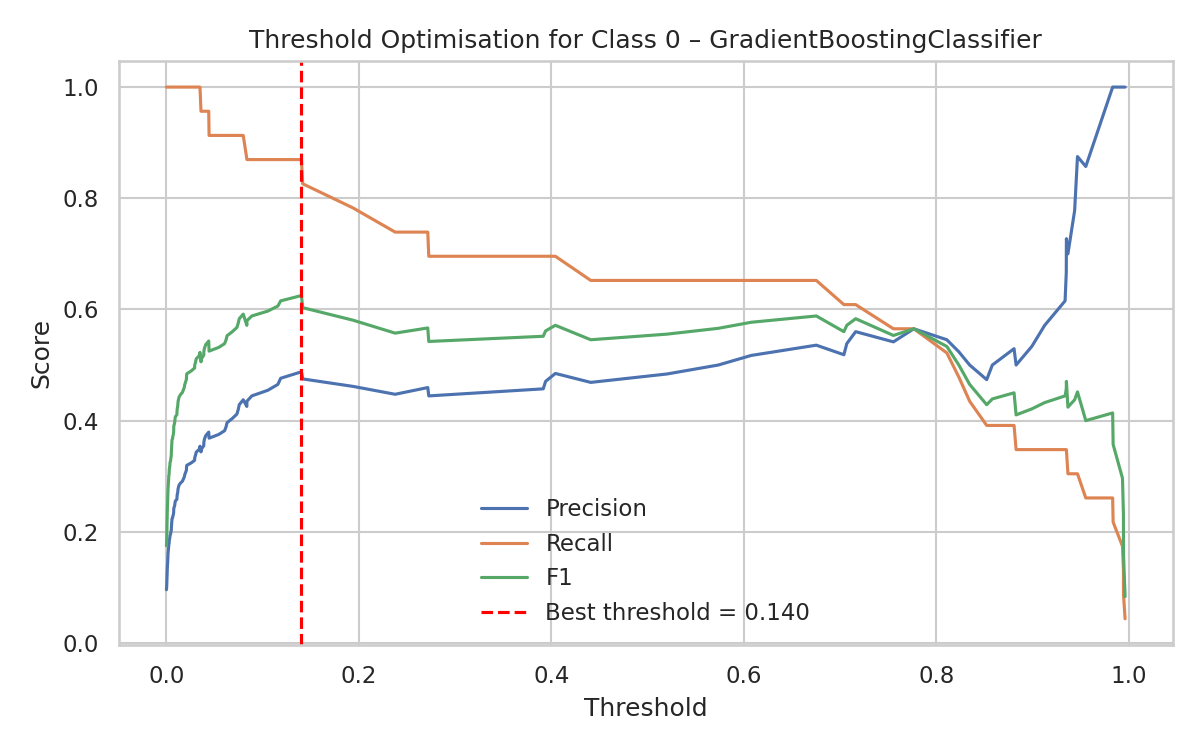

Displaying: threshold_tune_LogisticRegression.png


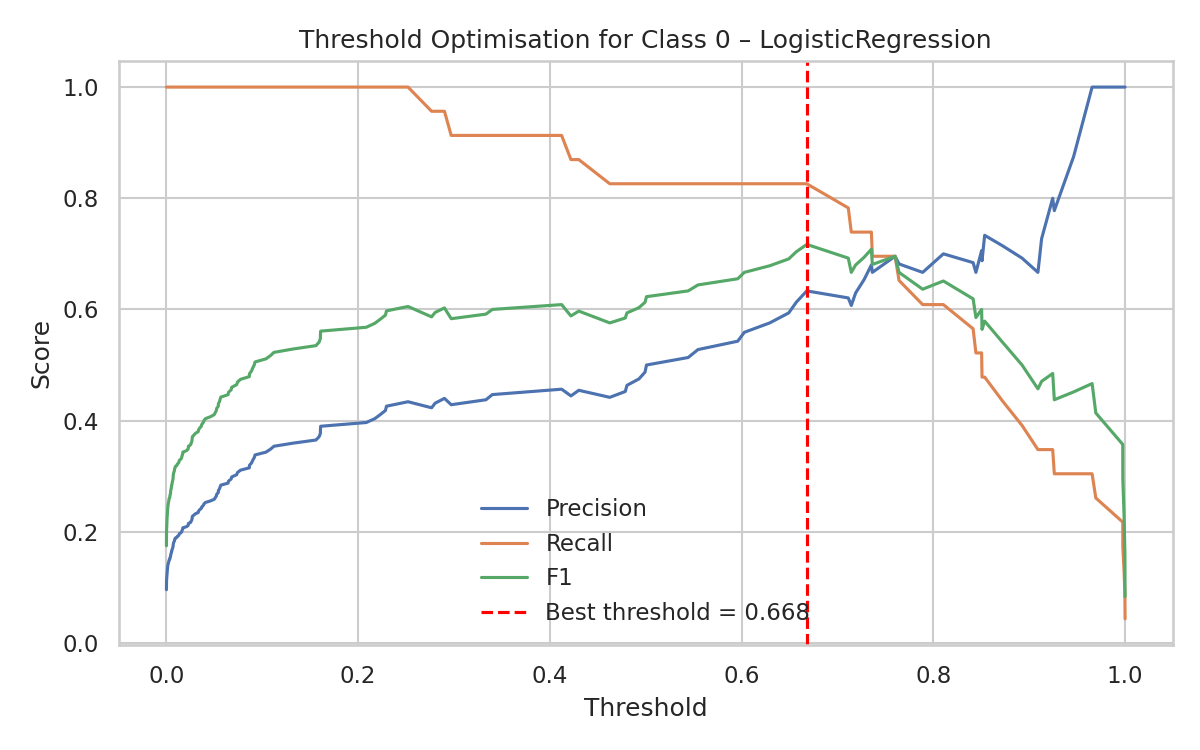

Displaying: threshold_tune_MLPClassifier.png


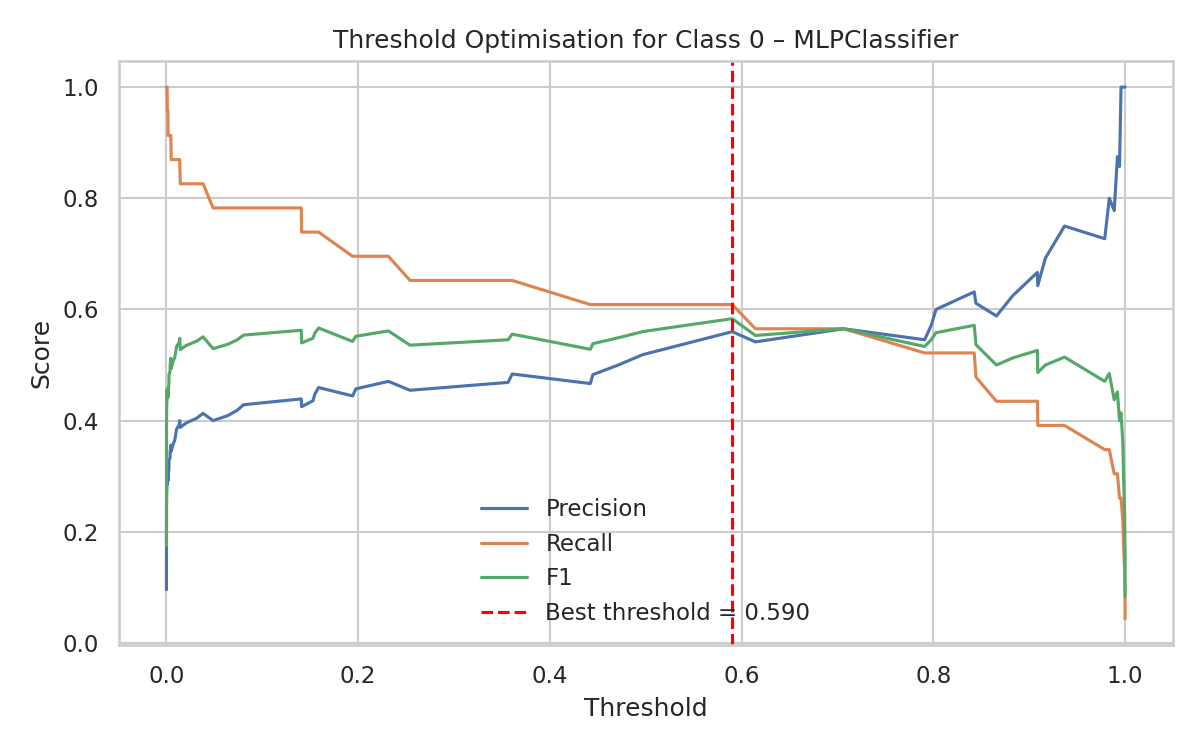

Displaying: threshold_tune_RandomForestClassifier.png


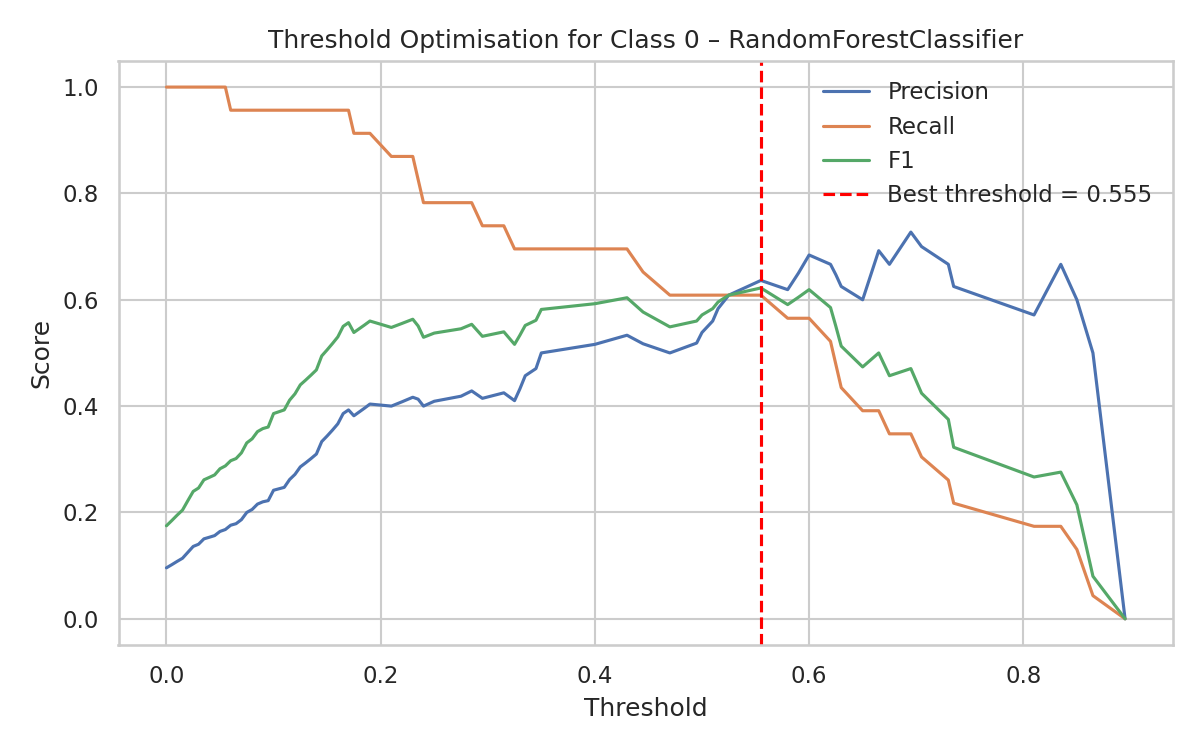

Displaying: threshold_tune_SVC.png


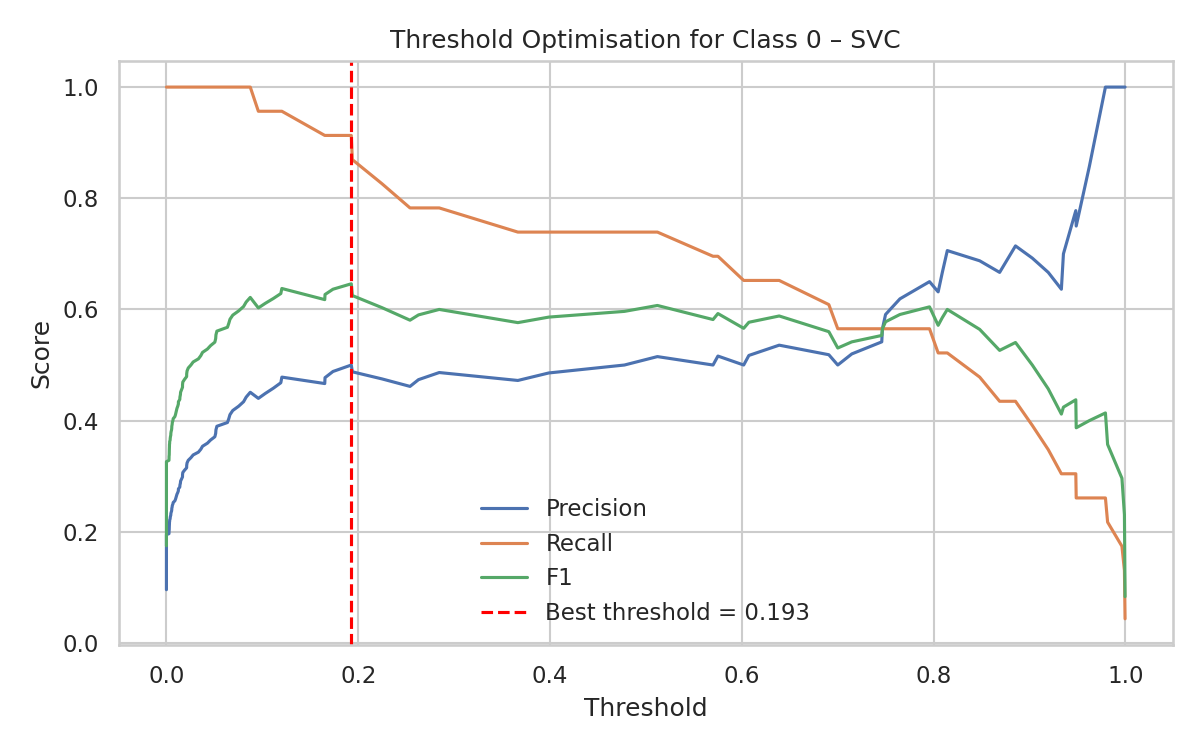


Done. Check the 'outputs' folder for all results and diagnostics.
Detailed model comparison saved to outputs/model_comparison_tuned.csv
Diagnostics saved to outputs/diagnostics.txt


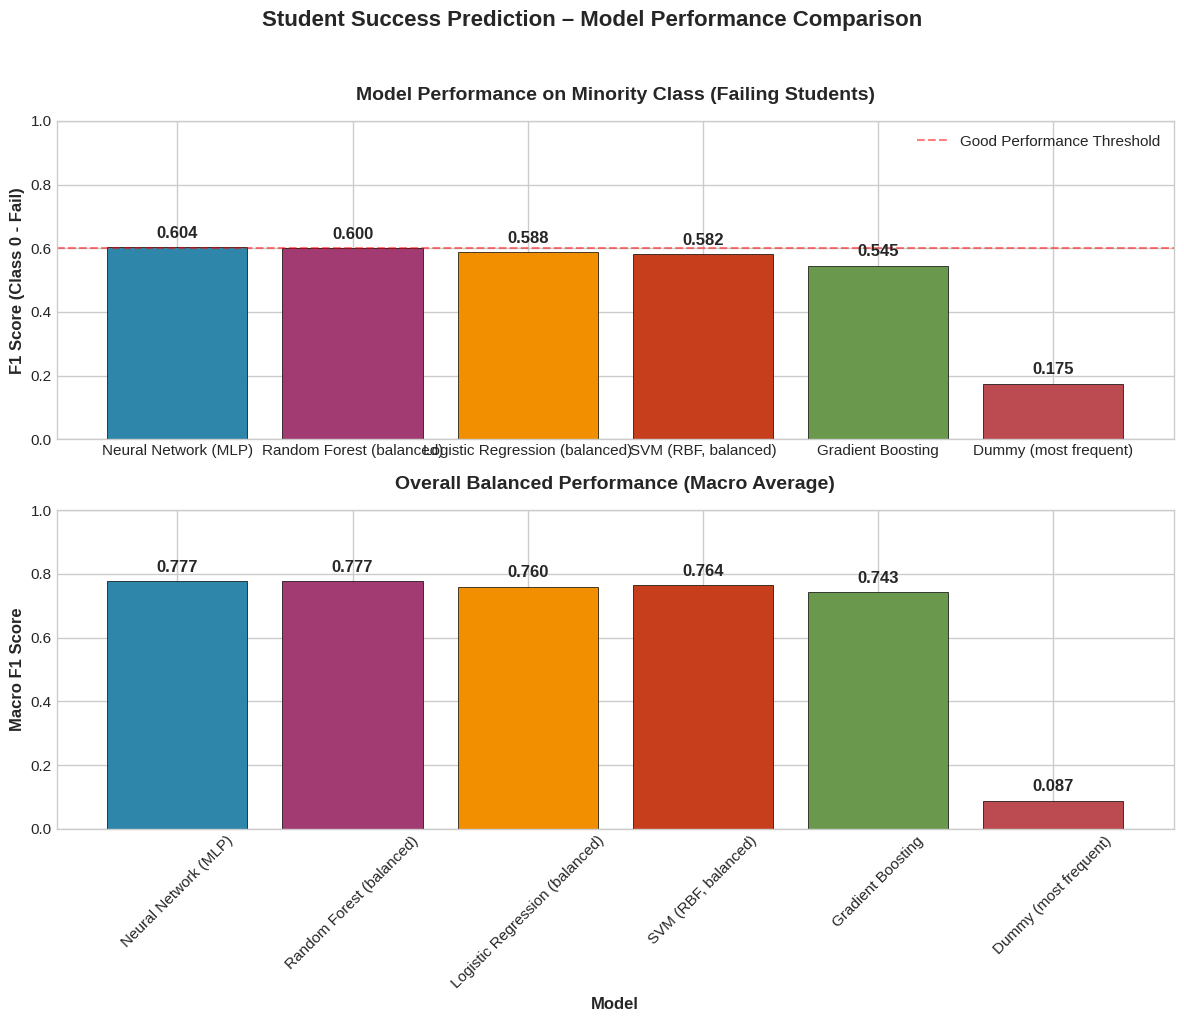

In [17]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, precision_recall_curve
)
import warnings
from IPython.display import Image, display

# For SMOTE
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️  imbalanced-learn not installed. SMOTE will be skipped. Install with: pip install imblearn")

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

DATA_FILE = "student_performance.csv"   # your cleaned file
OUTPUT_DIR = "outputs"

def safe_mkdir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}. Put your CSV in the same folder as this script.")
    df = pd.read_csv(path)
    return df

def clean_and_fill(df):
    df = df.drop_duplicates().reset_index(drop=True)
    cols = {c: c.strip() for c in df.columns}
    df.rename(columns=cols, inplace=True)
    df.replace(r'^[\s]*$', np.nan, regex=True, inplace=True)
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].isnull().any():
                df[col].fillna(df[col].mean(), inplace=True)
        else:
            if df[col].isnull().any():
                try:
                    df[col].fillna(df[col].mode(dropna=True)[0], inplace=True)
                except Exception:
                    df[col].fillna("Unknown", inplace=True)
    return df

def infer_target(df):
    pass_col = None
    for candidate in ["Pass", "pass", "PASS"]:
        if candidate in df.columns:
            pass_col = candidate
            break
    if pass_col:
        df['Pass'] = df[pass_col].apply(lambda x: int(x) if (str(x).strip() != "") else 0)
        return df, 'Pass'
    if 'Score' in df.columns:
        df['Pass'] = (pd.to_numeric(df['Score'], errors='coerce').fillna(0) >= 50).astype(int)
        return df, 'Pass'
    raise ValueError("No 'Pass' or 'Score' column found. Please include a 'Score' column or a 'Pass' (0/1) column in the CSV.")

def basic_eda_and_save(df):
    safe_mkdir(OUTPUT_DIR)
    print("\n-- Basic EDA --")
    print("Shape:", df.shape)
    print(df.describe(include='all').T)
    if 'Score' in df.columns:
        plt.figure(figsize=(8,5))
        sns.histplot(df['Score'].dropna(), bins=30, kde=True)
        plt.title("Score Distribution")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "score_distribution.png"), dpi=150)
        plt.close()
    if 'SchoolType' in df.columns and 'Score' in df.columns:
        plt.figure(figsize=(7,4))
        sns.boxplot(x='SchoolType', y='Score', data=df)
        plt.title("Score by School Type")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "score_by_schooltype.png"), dpi=150)
        plt.close()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) >= 2:
        plt.figure(figsize=(8,6))
        sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="Blues")
        plt.title("Correlation Heatmap (numeric)")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap.png"), dpi=150)
        plt.close()

def prepare_features(df, drop_id=True):
    candidate_id_cols = [c for c in df.columns if c.lower() in ('studentid', 'student_id', 'id')]
    if candidate_id_cols and drop_id:
        df = df.drop(columns=candidate_id_cols)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df_encoded

def find_optimal_threshold(model, X_val, y_val, metric='f1', target_class=0):
    """
    For a model that supports predict_proba, find threshold that maximizes
    the chosen metric for the specified class.
    Returns best_threshold and the corresponding metric value.
    """
    if not hasattr(model, "predict_proba"):
        return 0.5, None

    y_proba = model.predict_proba(X_val)[:, target_class]
    precisions, recalls, thresholds = precision_recall_curve(y_val == target_class, y_proba)

    if metric == 'f1':
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
        best_idx = np.argmax(f1_scores)
        best_thresh = thresholds[best_idx]
        best_score = f1_scores[best_idx]
    elif metric == 'recall':
        best_idx = np.argmax(recalls[:-1])
        best_thresh = thresholds[best_idx]
        best_score = recalls[best_idx]
    else:
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
        best_idx = np.argmax(f1_scores)
        best_thresh = thresholds[best_idx]
        best_score = f1_scores[best_idx]

    # Plot precision-recall vs threshold
    plt.figure(figsize=(8,5))
    plt.plot(thresholds, precisions[:-1], label='Precision')
    plt.plot(thresholds, recalls[:-1], label='Recall')
    if metric == 'f1':
        plt.plot(thresholds, f1_scores, label='F1')
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best threshold = {best_thresh:.3f}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Threshold Optimisation for Class {target_class} – {model.__class__.__name__}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"threshold_tune_{model.__class__.__name__}.png"), dpi=150)
    plt.close()

    return best_thresh, best_score

def compare_models(X, y, use_smote=True, tune_threshold=True):
    # First split: train+val vs test (60/20/20)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # Then split temp into train and validation (75/25 of remaining -> 60/20 of total)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
    )

    # Scale numeric features
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()
    if numeric_cols:
        X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
        X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
        X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    # Apply SMOTE to training data if requested and available
    if use_smote and SMOTE_AVAILABLE:
        print("\nApplying SMOTE to balance training data...")
        smote = SMOTE(random_state=42)
        X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)
        print(f"Training set after SMOTE: {X_train_scaled.shape[0]} samples")
    elif use_smote and not SMOTE_AVAILABLE:
        print("SMOTE requested but not available. Skipping.")

    # Define models (with class_weight='balanced' where supported)
    models = {
        'Dummy (most frequent)': DummyClassifier(strategy='most_frequent'),
        'Logistic Regression (balanced)': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
        'Random Forest (balanced)': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, random_state=42
        ),
        'SVM (RBF, balanced)': SVC(
            kernel='rbf', probability=True, class_weight='balanced', random_state=42
        ),
        'Neural Network (MLP)': MLPClassifier(
            hidden_layer_sizes=(100,), max_iter=500, random_state=42
        )
    }

    results = []
    predictions = {}
    threshold_info = {}

    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train_scaled, y_train)

        # Default predictions (threshold 0.5 for class 1)
        if hasattr(model, "predict_proba"):
            y_proba_test = model.predict_proba(X_test_scaled)
            y_pred_default = (y_proba_test[:, 1] >= 0.5).astype(int)
        else:
            y_pred_default = model.predict(X_test_scaled)

        # Compute default metrics
        acc_default = accuracy_score(y_test, y_pred_default)
        prec_per_class_default = precision_score(y_test, y_pred_default, average=None, zero_division=0)
        rec_per_class_default = recall_score(y_test, y_pred_default, average=None, zero_division=0)
        f1_per_class_default = f1_score(y_test, y_pred_default, average=None, zero_division=0)
        f1_macro_default = f1_score(y_test, y_pred_default, average='macro', zero_division=0)

        # Threshold tuning (if requested and model supports probabilities)
        best_thresh = 0.5
        f1_class0_tuned = f1_per_class_default[0]
        y_pred_tuned = y_pred_default
        if tune_threshold and hasattr(model, "predict_proba"):
            # Find best threshold on validation set
            best_thresh, _ = find_optimal_threshold(model, X_val_scaled, y_val, metric='f1', target_class=0)
            threshold_info[name] = best_thresh
            # Apply to test set
            y_proba_test_class0 = model.predict_proba(X_test_scaled)[:, 0]
            y_pred_tuned = (y_proba_test_class0 >= best_thresh).astype(int)

            # Compute tuned metrics
            f1_per_class_tuned = f1_score(y_test, y_pred_tuned, average=None, zero_division=0)
            f1_class0_tuned = f1_per_class_tuned[0]
            f1_macro_tuned = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
        else:
            f1_class0_tuned = f1_per_class_default[0]
            f1_macro_tuned = f1_macro_default

        # Store results
        results.append({
            'Model': name,
            'Accuracy (default)': acc_default,
            'F1 (class0) default': f1_per_class_default[0],
            'F1 (class1) default': f1_per_class_default[1],
            'F1 (macro) default': f1_macro_default,
            'F1 (class0) tuned': f1_class0_tuned,
            'F1 (macro) tuned': f1_macro_tuned,
            'Best threshold (class0)': best_thresh if tune_threshold and hasattr(model, "predict_proba") else 'N/A'
        })
        predictions[name] = {'default': y_pred_default, 'tuned': y_pred_tuned if tune_threshold else y_pred_default}

        # Save confusion matrices for default and tuned
        for suffix, y_pred in [('default', y_pred_default), ('tuned', y_pred_tuned)]:
            cm = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(4,3))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f"Confusion Matrix - {name} ({suffix})")
            plt.xlabel("Predicted"); plt.ylabel("Actual")
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, f"cm_{name.replace(' ', '_')}_{suffix}.png"), dpi=150)
            plt.close()

    # Create comparison DataFrame
    results_df = pd.DataFrame(results)
    sort_col = 'F1 (macro) tuned' if tune_threshold else 'F1 (macro) default'
    results_df = results_df.sort_values(sort_col, ascending=False)

    print("\n=== Model Comparison (with threshold tuning) ===")
    display_cols = ['Model', 'F1 (class0) default', 'F1 (class0) tuned', 'F1 (macro) default', 'F1 (macro) tuned', 'Best threshold (class0)']
    print(results_df[display_cols].to_string(index=False))

    # Save full table
    results_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_tuned.csv"), index=False)

    # Plot comparison of default vs tuned F1 for class 0
    plt.figure(figsize=(10,6))
    x = np.arange(len(results_df))
    width = 0.35
    plt.bar(x - width/2, results_df['F1 (class0) default'], width, label='F1 (class0) default')
    plt.bar(x + width/2, results_df['F1 (class0) tuned'], width, label='F1 (class0) tuned')
    plt.xlabel('Model')
    plt.ylabel('F1 Score for Class 0 (Fail)')
    plt.title('Impact of Threshold Tuning on Minority Class Detection')
    plt.xticks(x, results_df['Model'], rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "threshold_impact.png"), dpi=150)
    plt.close()

    return results_df, predictions, threshold_info, (X_test, y_test)

def main():
    safe_mkdir(OUTPUT_DIR)
    try:
        df = load_data(DATA_FILE)
    except Exception as e:
        print("ERROR loading data:", e)
        sys.exit(1)

    print("Loaded dataset with shape:", df.shape)
    print("Columns:", df.columns.tolist())

    df = clean_and_fill(df)

    try:
        df, target_col = infer_target(df)
        print(f"Using target column: '{target_col}'")
    except Exception as e:
        print("ERROR inferring target:", e)
        print("If your CSV has a different target column, add it named 'Pass' (0/1) or add a 'Score' column.")
        sys.exit(1)

    # ----- DIAGNOSTIC 1: Class distribution -----
    class_dist = df[target_col].value_counts(normalize=True)
    print("\n=== Class Distribution ===")
    print(class_dist)
    if class_dist.min() < 0.1:
        print("⚠️  Warning: One class dominates (<10%). Accuracy may be misleading. Focus on per-class and macro F1.")

    basic_eda_and_save(df)

    # Save cleaned data
    df.to_csv(os.path.join(OUTPUT_DIR, "cleaned_student_data.csv"), index=False)

    # Prepare features (remove target and Score to avoid leakage)
    y = df[target_col]
    X_df = df.drop(columns=[target_col, 'Score'], errors='ignore')
    X_encoded = prepare_features(X_df, drop_id=True)

    # Drop constant columns
    nunique = X_encoded.nunique()
    cols_to_drop = nunique[nunique <= 1].index.tolist()
    if cols_to_drop:
        X_encoded.drop(columns=cols_to_drop, inplace=True)

    print("\nFinal feature matrix shape:", X_encoded.shape)
    print("Features used:")
    print(X_encoded.columns.tolist())

    if X_encoded.shape[0] < 10:
        print("Not enough rows to train models. Need more data.")
        sys.exit(1)

    # ----- DIAGNOSTIC 2: Quick feature importance check (Random Forest) -----
    print("\n=== Quick Feature Importance Check (Random Forest) ===")
    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
        X_encoded, y, test_size=0.25, random_state=42, stratify=y
    )
    rf_check = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_check.fit(X_train_rf, y_train_rf)
    importances = pd.Series(rf_check.feature_importances_, index=X_encoded.columns)
    top_features = importances.sort_values(ascending=False).head(10)
    print("Top 10 feature importances:")
    print(top_features)
    if top_features.iloc[0] > 0.9:
        print("⚠️  Warning: A single feature dominates (>0.9). Possible data leakage!")

    # Compare models with SMOTE and threshold tuning
    results_df, predictions, threshold_info, (X_test, y_test) = compare_models(
        X_encoded, y, use_smote=True, tune_threshold=True
    )

    # Save diagnostics
    with open(os.path.join(OUTPUT_DIR, "diagnostics.txt"), "w") as f:
        f.write("=== DIAGNOSTICS ===\n")
        f.write("\nClass distribution:\n")
        f.write(class_dist.to_string())
        f.write("\n\nFeatures used:\n")
        f.write(str(X_encoded.columns.tolist()))
        f.write("\n\nTop 10 feature importances (RF):\n")
        f.write(top_features.to_string())
        f.write("\n\nThreshold info:\n")
        for model, thresh in threshold_info.items():
            f.write(f"{model}: {thresh:.4f}\n")
        if class_dist.min() < 0.1:
            f.write("\n⚠️  Class imbalance detected. Accuracy is not reliable.\n")
        if top_features.iloc[0] > 0.9:
            f.write("\n⚠️  Possible data leakage: a single feature dominates.\n")

    # Display generated images
    print("\n--- Generated Plots ---")
    for fname in sorted(os.listdir(OUTPUT_DIR)):
        if fname.endswith(".png"):
            print(f"Displaying: {fname}")
            display(Image(os.path.join(OUTPUT_DIR, fname)))

    print("\nDone. Check the 'outputs' folder for all results and diagnostics.")
    print("Detailed model comparison saved to outputs/model_comparison_tuned.csv")
    print("Diagnostics saved to outputs/diagnostics.txt")

if __name__ == "__main__":
    main()

    import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load your results
results = pd.read_csv('outputs/model_comparison_tuned.csv')

# Sort by F1 class0 for better presentation
results = results.sort_values('F1 (class0) default', ascending=False)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']

# Create figure with 2 subplots vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1: F1 (class0) default
bars1 = ax1.bar(results['Model'], results['F1 (class0) default'],
                color=colors[:len(results)], edgecolor='black', linewidth=0.5)
ax1.set_ylabel('F1 Score (Class 0 - Fail)', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance on Minority Class (Failing Students)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.6, color='red', linestyle='--', alpha=0.5, label='Good Performance Threshold')
ax1.legend()

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Chart 2: F1 (macro) default
bars2 = ax2.bar(results['Model'], results['F1 (macro) default'],
                color=colors[:len(results)], edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_title('Overall Balanced Performance (Macro Average)',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Student Success Prediction – Model Performance Comparison',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/linkedin_model_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('outputs/linkedin_model_comparison.jpg', dpi=300, bbox_inches='tight')
plt.show()